## Задание 2
## Визуальный анализ данных
**Цель работы:** изучить программные средства, используемые для визуализации наборов данных

Выполним анализ набора данных bank.csv. Набор данных связан с кампаниями прямого маркетинга банковского учреждения. Маркетинговые кампании были основаны на телефонных звонках. Часто требовалось более одного контакта с одним и тем же клиентом, чтобы узнать, будет ли у него подписка на продукт (банковский срочный депозит). Цель классификации – предсказать, подпишется ли клиент на срочный депозит (переменная у). Набор данных включает ледующие атрибуты:

*Данные банковского клиента:*
* age – возраст (числовой)
* job – тип работы (категория: "администратор", "неизвестный", "безработный", "менеджер", "горничная", "предприниматель", "студент", "рабочий", "самозанятый", "пенсионер", "техник", "услуги")
* marital – семейное положение (категория: "женат", "разведен", "холост"; примечание: "разведен" означает разведенный или овдовевший)
* education – образование (категория: "неизвестно", "среднее", "начальное",
"высшее")
* default – просрочен ли кредит? (двоичный код: "да", "нет")
* balance – среднегодовой баланс в евро (числовой)
* housing – есть ссуда на жилье? (двоичные значения: "да", "нет")
* loan – есть ссуда на личные нужды? (двоичные значения: "да", "нет")

*Последний контакт в рамках текущей кампании:*
* contact – тип связи с контактом (категория: "неизвестно", "телефон", "сотовый")
* day – последний день контакта в месяце (числовой)
* month – месяц последнего контакта в году (категория: "январь", "февраль",
"март", ... , "ноябрь", "декабрь")
* duration – продолжительность последнего контакта в секундах (числовая)

*Другие атрибуты:*
* campaign – количество контактов, осуществленных в ходе этой кампании и для
данного клиента (числовой, включает последний контакт)
* pdays – количество дней, прошедших с момента последнего контакта с клиентом в рамках предыдущей кампании (числовой, -1 означает, что ранее с клиентом не связывались)
* previous количество контактов, осуществленных до этой кампании и для данного клиента (числовой)
* poutcome – результат предыдущей маркетинговой кампании (категория: "неизвестно", "другое", "неудача", "успех")

*Выходная переменная (целевая):*
* у – клиент подпишется на срочный депозит? (двоичный код: "да", "нет")

## 1. Импорт необходимых библиотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка отображения графиков
%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
# Настройка отображения pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("Библиотеки успешно загружены")

Библиотеки успешно загружены


## 2. Загрузка данных

In [2]:
from google.colab import files

# Загружаем файл bank.csv
print("Пожалуйста, загрузите файл bank.csv")
uploaded = files.upload()

# Читаем файл
import io
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]), sep=';')

print(f"\nФайл '{filename}' успешно загружен")
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")

Пожалуйста, загрузите файл bank.csv


Saving bank.csv to bank.csv

Файл 'bank.csv' успешно загружен
Размер датасета: 4521 строк, 17 столбцов


## 3. Первичный анализ данных

In [3]:
print("="*60)
print("ПЕРВИЧНЫЙ АНАЛИЗ ДАННЫХ")
print("="*60)

print("\nПервые 5 записей:")
print(df.head())

print("\n" + "="*60)
print("ИНФОРМАЦИЯ О ДАТАФРЕЙМЕ:")
print("="*60)
df.info()

print("\n" + "="*60)
print("СТАТИСТИЧЕСКОЕ ОПИСАНИЕ ЧИСЛОВЫХ ПРИЗНАКОВ:")
print("="*60)
print(df.describe())

print("\n" + "="*60)
print("ПРОПУЩЕННЫЕ ЗНАЧЕНИЯ:")
print("="*60)
print(df.isnull().sum())

print("\n" + "="*60)
print("УНИКАЛЬНЫЕ ЗНАЧЕНИЯ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ:")
print("="*60)
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\n{col}: {df[col].unique()[:10]}")

ПЕРВИЧНЫЙ АНАЛИЗ ДАННЫХ

Первые 5 записей:
   age          job  marital  education default  balance housing loan  \
0   30   unemployed  married    primary      no     1787      no   no   
1   33     services  married  secondary      no     4789     yes  yes   
2   35   management   single   tertiary      no     1350     yes   no   
3   30   management  married   tertiary      no     1476     yes  yes   
4   59  blue-collar  married  secondary      no        0     yes   no   

    contact  day month  duration  campaign  pdays  previous poutcome   y  
0  cellular   19   oct        79         1     -1         0  unknown  no  
1  cellular   11   may       220         1    339         4  failure  no  
2  cellular   16   apr       185         1    330         1  failure  no  
3   unknown    3   jun       199         4     -1         0  unknown  no  
4   unknown    5   may       226         1     -1         0  unknown  no  

ИНФОРМАЦИЯ О ДАТАФРЕЙМЕ:
<class 'pandas.core.frame.DataFrame'>
Rang

## 4. Визуализация целевой переменной

/tmp/ipykernel_8256/624185676.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='y', ax=axes[1], palette=['#ff9999', '#66b3ff'])


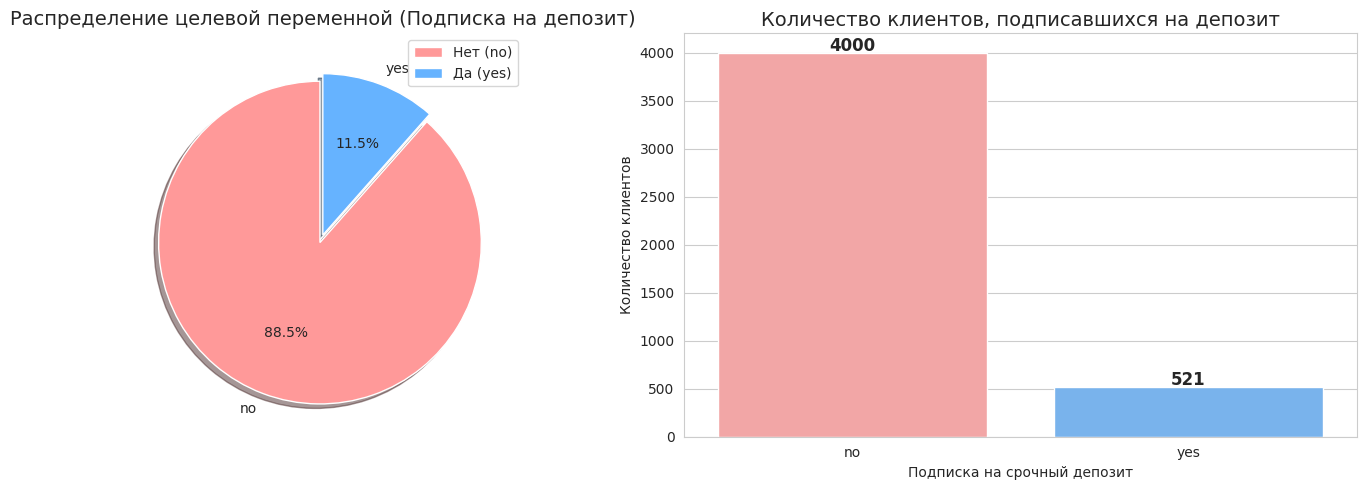


Распределение целевой переменной:
y
no     4000
yes     521
Name: count, dtype: int64

Доля подписавшихся: 11.52%


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Круговая диаграмма
colors = ['#ff9999', '#66b3ff']
df['y'].value_counts().plot(
    kind='pie',
    ax=axes[0],
    autopct='%1.1f%%',
    colors=colors,
    explode=(0.05, 0),
    shadow=True,
    startangle=90
)
axes[0].set_title('Распределение целевой переменной (Подписка на депозит)', fontsize=14)
axes[0].set_ylabel('')
axes[0].legend(['Нет (no)', 'Да (yes)'], loc='upper right')

# Столбчатая диаграмма
sns.countplot(data=df, x='y', ax=axes[1], palette=['#ff9999', '#66b3ff'])
axes[1].set_title('Количество клиентов, подписавшихся на депозит', fontsize=14)
axes[1].set_xlabel('Подписка на срочный депозит')
axes[1].set_ylabel('Количество клиентов')

# Добавление значений на столбцы
for i, v in enumerate(df['y'].value_counts().values):
    axes[1].text(i, v + 20, str(v), ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nРаспределение целевой переменной:")
print(df['y'].value_counts())
print(f"\nДоля подписавшихся: {df['y'].value_counts(normalize=True)['yes']*100:.2f}%")

## 5. Визуализация распределения числовых признаков

Числовые признаки: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


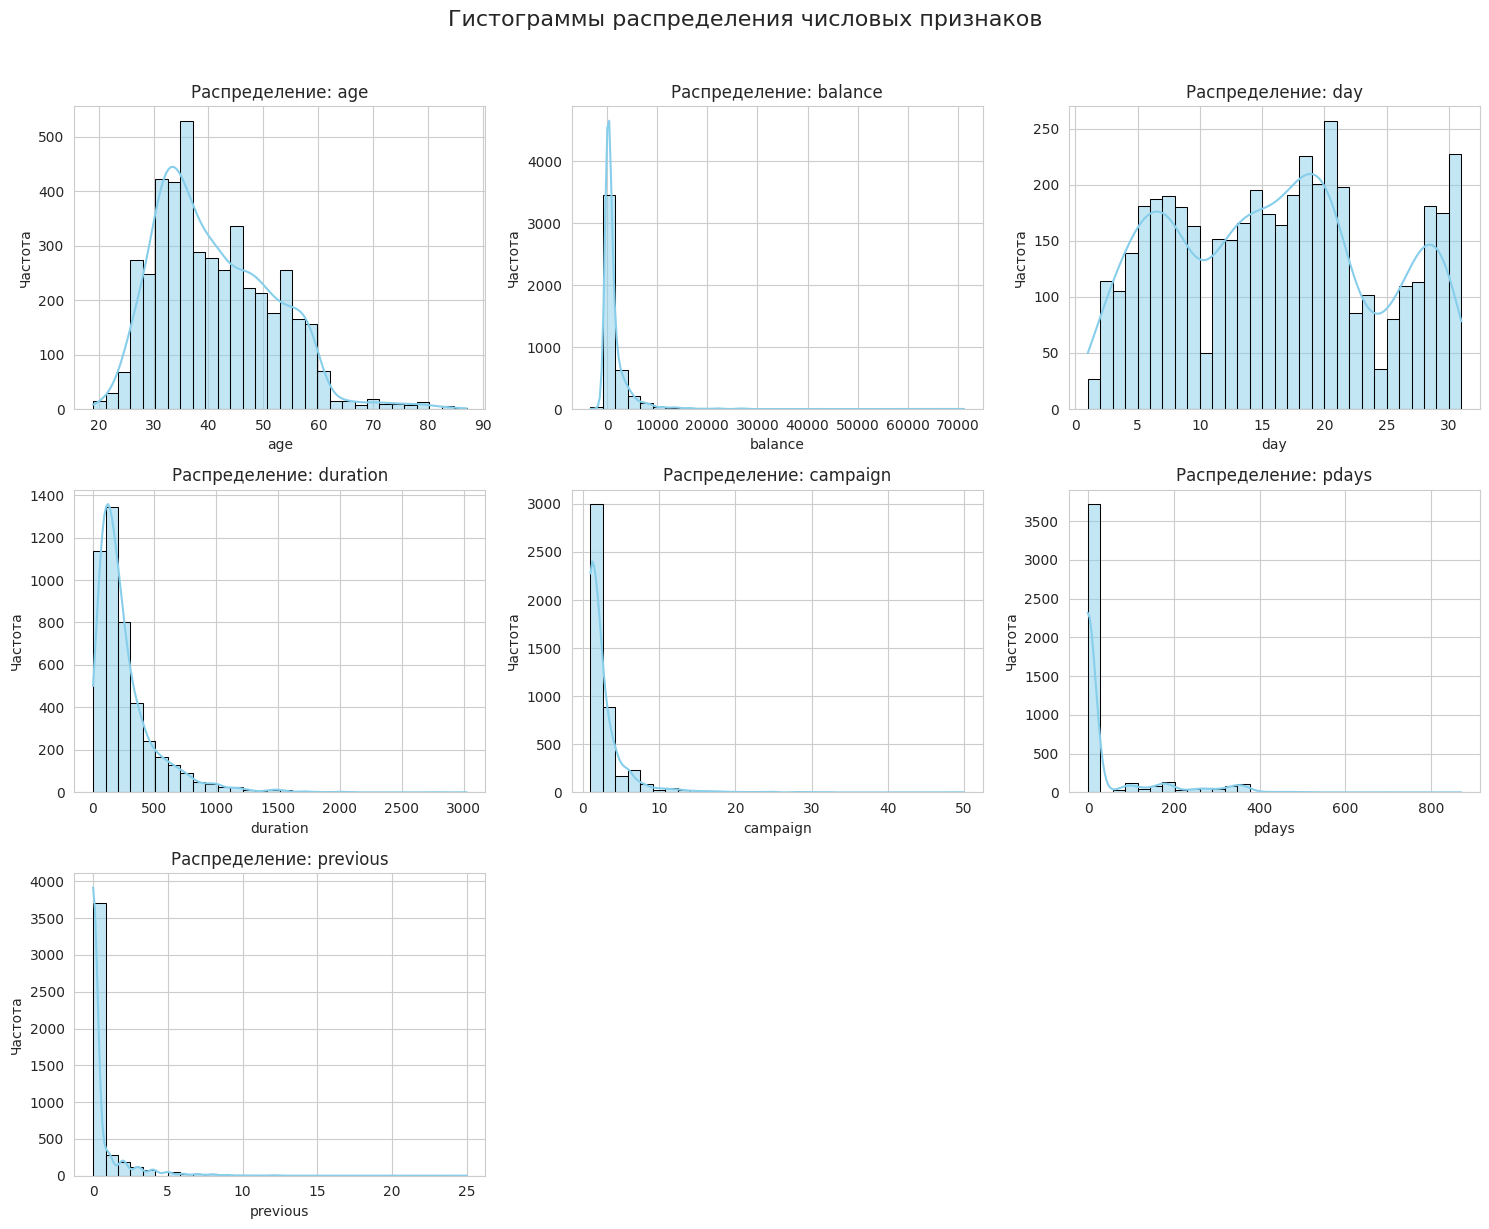

In [5]:
# Выбираем числовые признаки
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Числовые признаки:", list(numeric_cols))

# Гистограммы для всех числовых признаков
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    if i < len(axes):
        sns.histplot(df[col], bins=30, kde=True, ax=axes[i], color='skyblue', edgecolor='black')
        axes[i].set_title(f'Распределение: {col}', fontsize=12)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Частота')

# Скрываем лишние подграфики
for i in range(len(numeric_cols), len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Гистограммы распределения числовых признаков', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 6. Boxplot для выявления выбросов

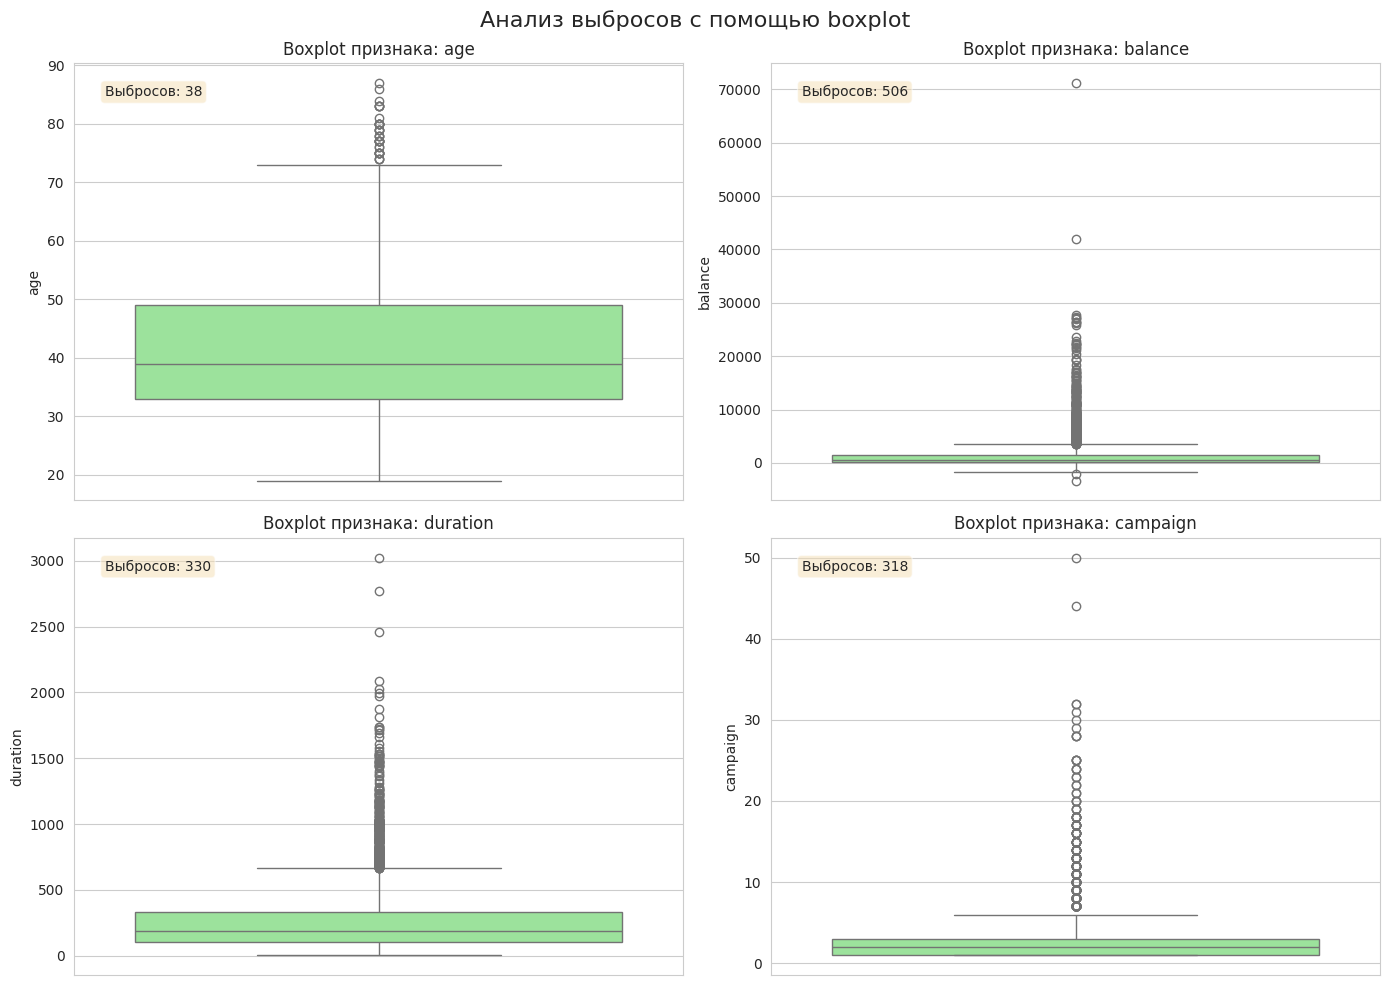

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

boxplot_cols = ['age', 'balance', 'duration', 'campaign']

for i, col in enumerate(boxplot_cols):
    sns.boxplot(data=df, y=col, ax=axes[i], color='lightgreen')
    axes[i].set_title(f'Boxplot признака: {col}', fontsize=12)

    # Добавление статистики
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    axes[i].text(0.05, 0.95, f'Выбросов: {outliers}', transform=axes[i].transAxes,
                 fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Анализ выбросов с помощью boxplot', fontsize=16)
plt.tight_layout()
plt.show()

## 7. Анализ категориальных признаков

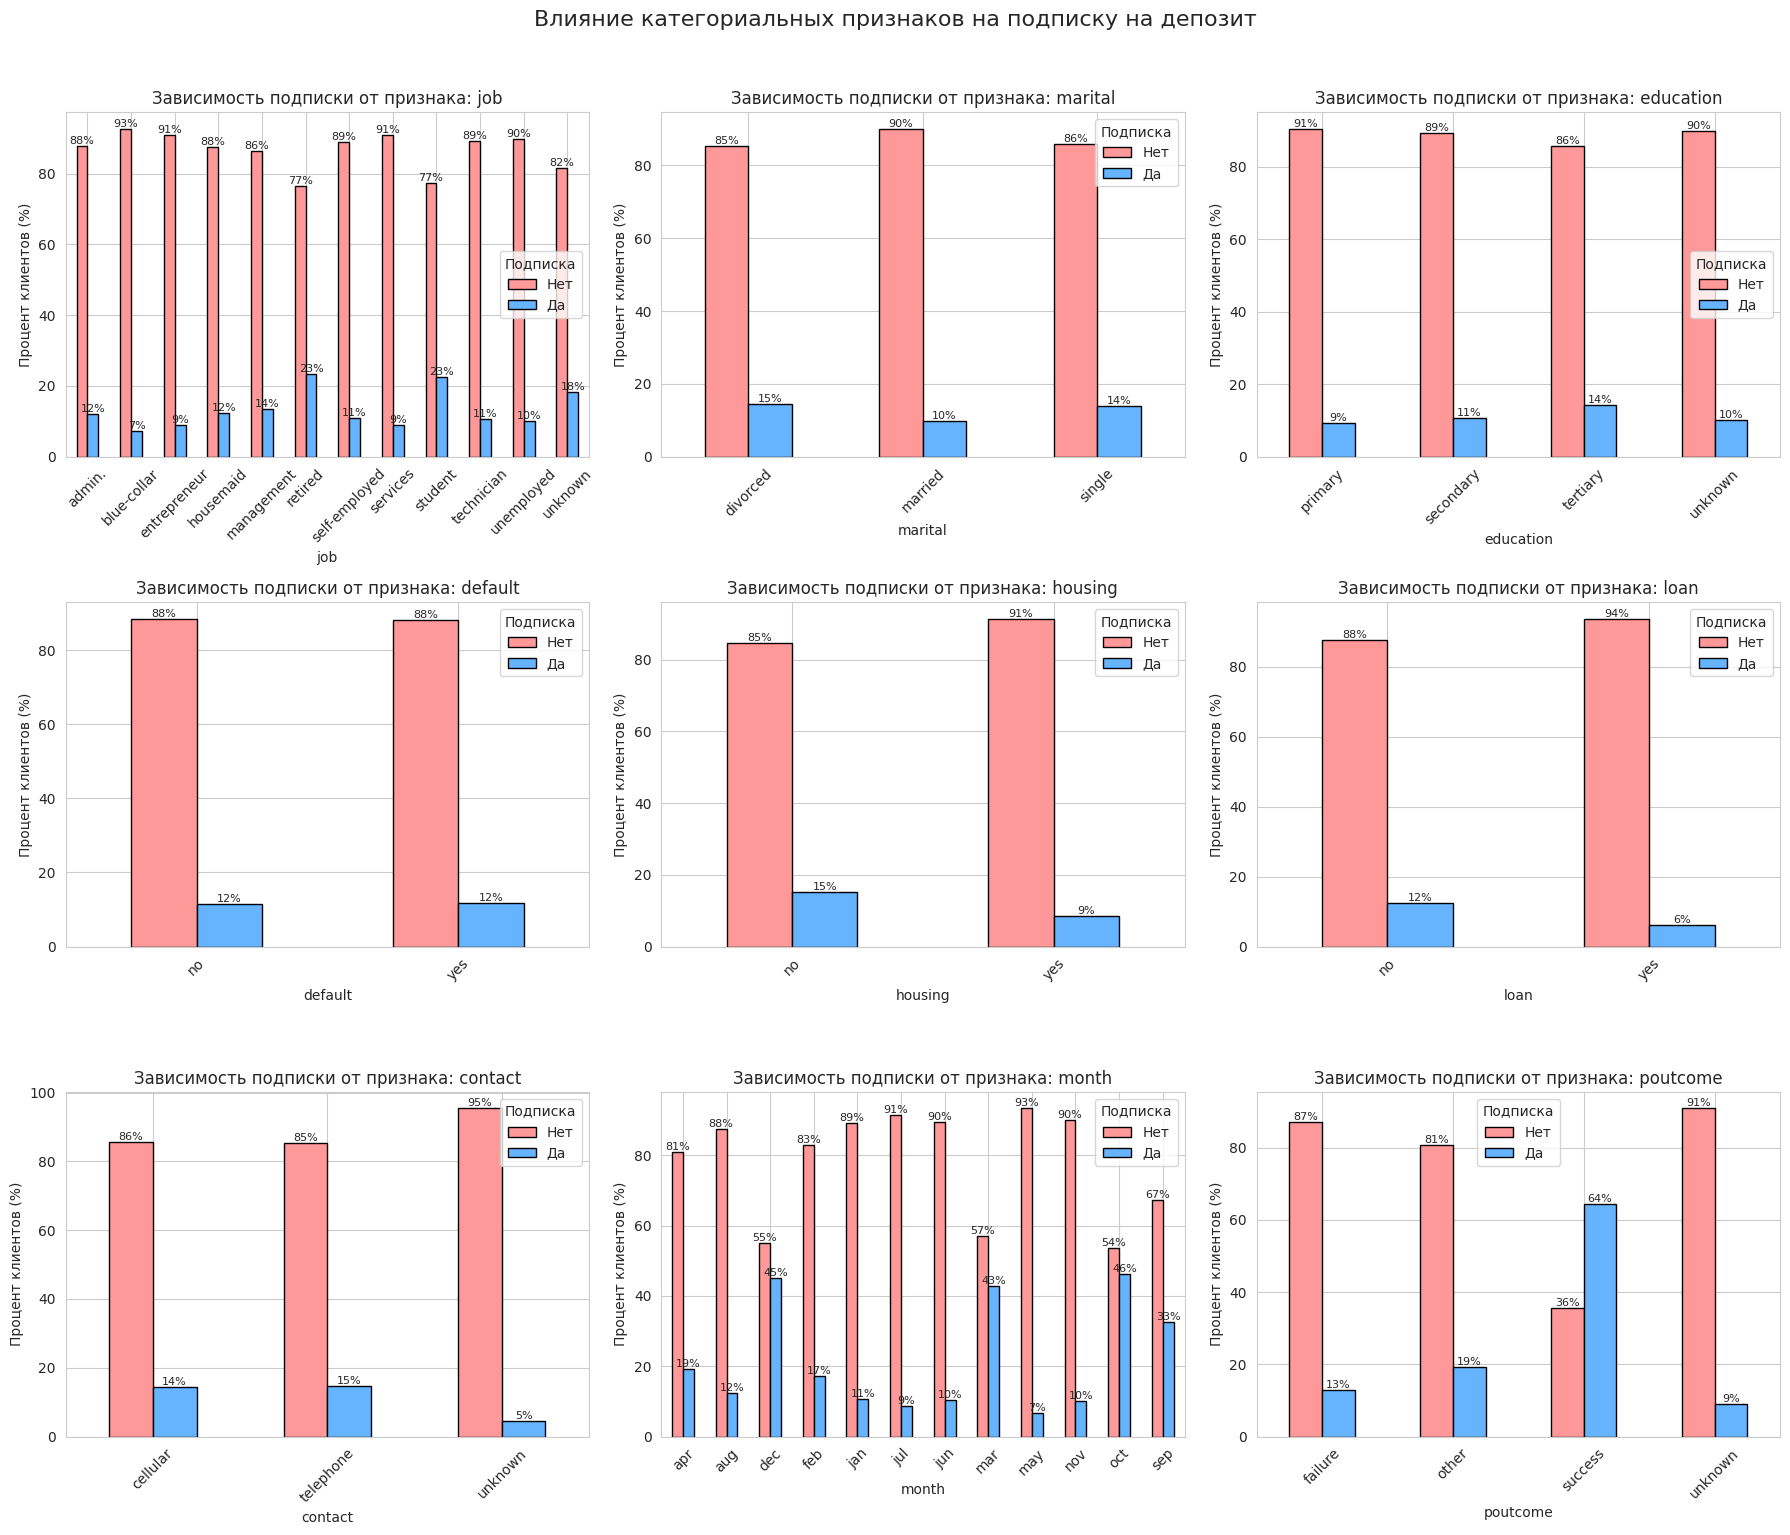

In [7]:
categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

# Создаем сетку графиков
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    # Создаем кросс-таблицу с целевой переменной
    cross_tab = pd.crosstab(df[col], df['y'], normalize='index') * 100

    # Столбчатая диаграмма с группировкой
    cross_tab.plot(kind='bar', ax=axes[i], color=['#ff9999', '#66b3ff'], edgecolor='black')
    axes[i].set_title(f'Зависимость подписки от признака: {col}', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Процент клиентов (%)')
    axes[i].legend(title='Подписка', labels=['Нет', 'Да'])
    axes[i].tick_params(axis='x', rotation=45)

    # Добавление значений на столбцы
    for j, container in enumerate(axes[i].containers):
        axes[i].bar_label(container, fmt='%.0f%%', fontsize=8)

plt.suptitle('Влияние категориальных признаков на подписку на депозит', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 8. Анализ связи числовых признаков с целевой переменной

/tmp/ipykernel_8256/3471060664.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='y', y=col, ax=axes[i], palette=['#ff9999', '#66b3ff'])
/tmp/ipykernel_8256/3471060664.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='y', y=col, ax=axes[i], palette=['#ff9999', '#66b3ff'])
/tmp/ipykernel_8256/3471060664.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='y', y=col, ax=axes[i], palette=['#ff9999', '#66b3ff'])
/tmp/ipykernel_8256/3471060664.py:8: FutureWarning: 

Passing `palette` without assigning `hue` i

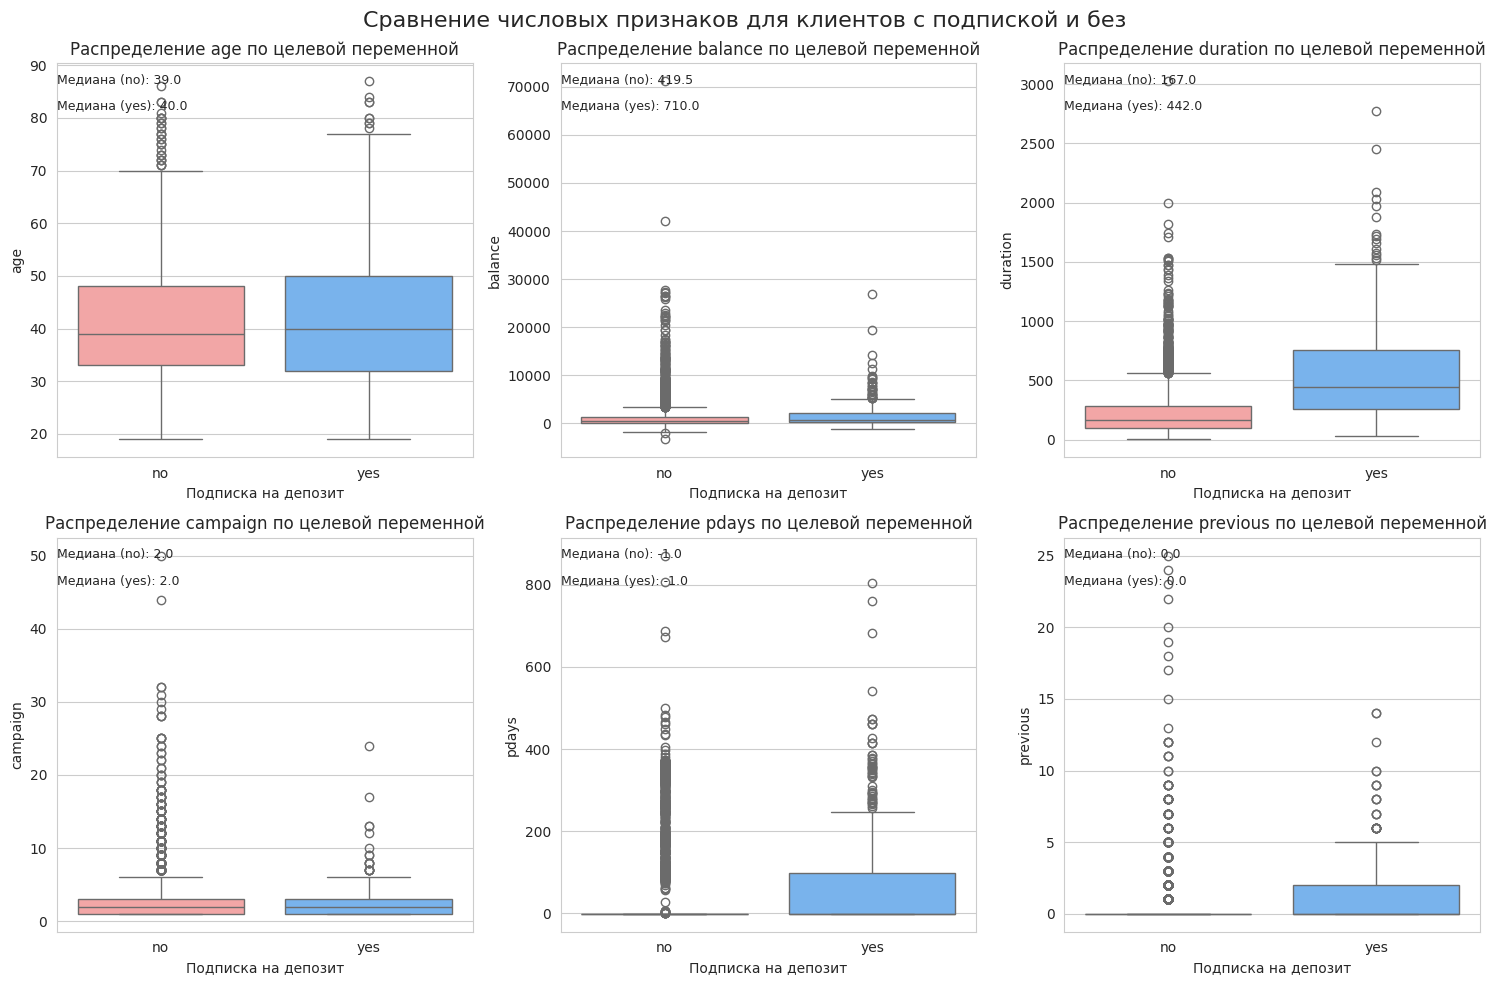

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

numeric_for_analysis = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']

for i, col in enumerate(numeric_for_analysis):
    # Boxplot для сравнения групп
    sns.boxplot(data=df, x='y', y=col, ax=axes[i], palette=['#ff9999', '#66b3ff'])
    axes[i].set_title(f'Распределение {col} по целевой переменной', fontsize=12)
    axes[i].set_xlabel('Подписка на депозит')
    axes[i].set_ylabel(col)

    # Добавление медиан
    median_no = df[df['y']=='no'][col].median()
    median_yes = df[df['y']=='yes'][col].median()
    axes[i].text(0, 0.95, f'Медиана (no): {median_no:.1f}', transform=axes[i].transAxes, fontsize=9)
    axes[i].text(0, 0.88, f'Медиана (yes): {median_yes:.1f}', transform=axes[i].transAxes, fontsize=9)

plt.suptitle('Сравнение числовых признаков для клиентов с подпиской и без', fontsize=16)
plt.tight_layout()
plt.show()

## 9. Корреляционный анализ

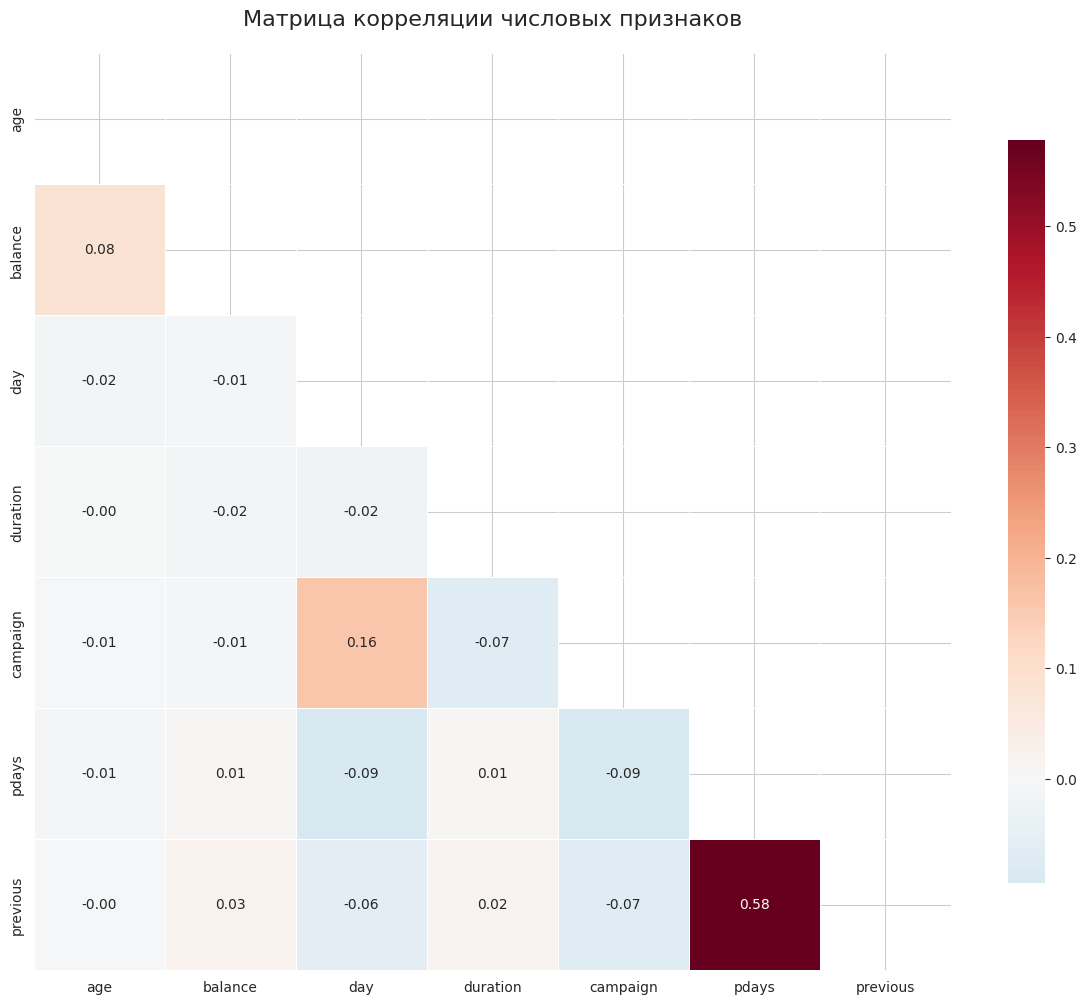


НАИБОЛЕЕ СИЛЬНЫЕ КОРРЕЛЯЦИИ:
pdays — previous: 0.578
previous — pdays: 0.578


In [9]:
# Вычисляем корреляционную матрицу
corr_matrix = df[numeric_cols].corr()

# Тепловая карта корреляций
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='RdBu_r',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8},
            ax=ax)
ax.set_title('Матрица корреляции числовых признаков', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# Выводим наиболее сильные корреляции
print("\n" + "="*60)
print("НАИБОЛЕЕ СИЛЬНЫЕ КОРРЕЛЯЦИИ:")
print("="*60)
corr_pairs = corr_matrix.unstack().sort_values(kind="quicksort", ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1]  # убираем диагональ
for pair, corr in corr_pairs.head(10).items():
    if corr > 0.3 or corr < -0.3:
        print(f"{pair[0]} — {pair[1]}: {corr:.3f}")

## 10. Анализ продолжительности разговора (duration)

/tmp/ipykernel_8256/998163665.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='y', y='duration', ax=axes[1], palette=['#ff9999', '#66b3ff'])


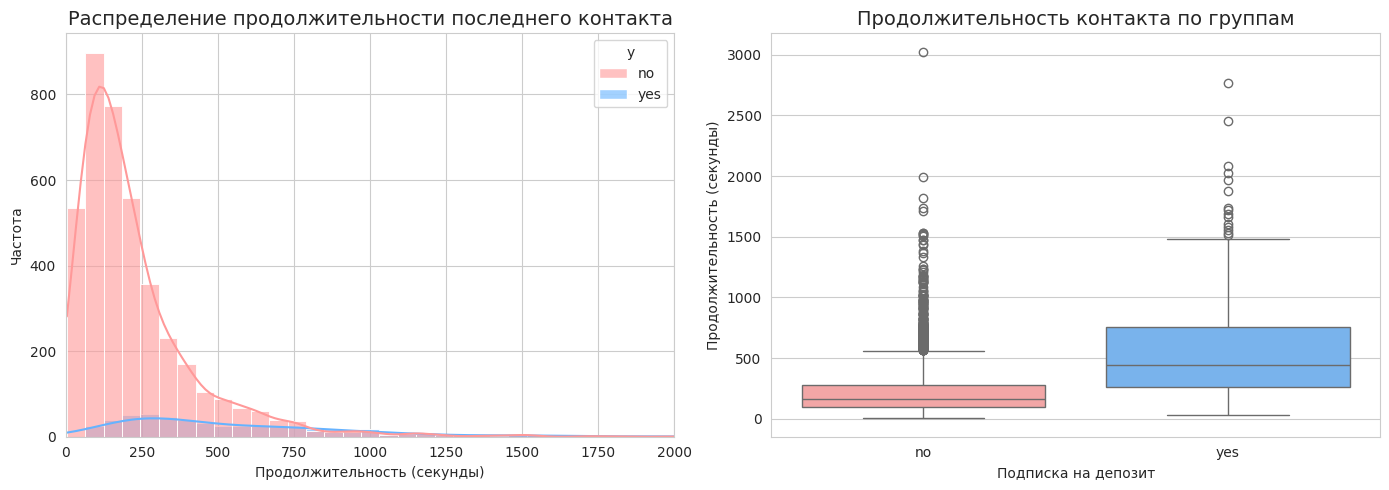

Средняя продолжительность разговора для подписавшихся: 552.7 сек
Средняя продолжительность разговора для неподписавшихся: 226.3 сек


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма продолжительности разговора с разделением по целевой переменной
sns.histplot(data=df, x='duration', hue='y', bins=50, kde=True, ax=axes[0],
             palette=['#ff9999', '#66b3ff'], alpha=0.6)
axes[0].set_title('Распределение продолжительности последнего контакта', fontsize=14)
axes[0].set_xlabel('Продолжительность (секунды)')
axes[0].set_ylabel('Частота')
axes[0].set_xlim(0, 2000)

sns.boxplot(data=df, x='y', y='duration', ax=axes[1], palette=['#ff9999', '#66b3ff'])
axes[1].set_title('Продолжительность контакта по группам', fontsize=14)
axes[1].set_xlabel('Подписка на депозит')
axes[1].set_ylabel('Продолжительность (секунды)')

plt.tight_layout()
plt.show()

print(f"Средняя продолжительность разговора для подписавшихся: {df[df['y']=='yes']['duration'].mean():.1f} сек")
print(f"Средняя продолжительность разговора для неподписавшихся: {df[df['y']=='no']['duration'].mean():.1f} сек")

## 11. Анализ месяца последнего контакта

/tmp/ipykernel_8256/1114920025.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=month_counts.index, y=month_counts.values, ax=axes[0], palette='viridis')
/tmp/ipykernel_8256/1114920025.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=month_success.index, y=month_success.values, ax=axes[1], palette='coolwarm')


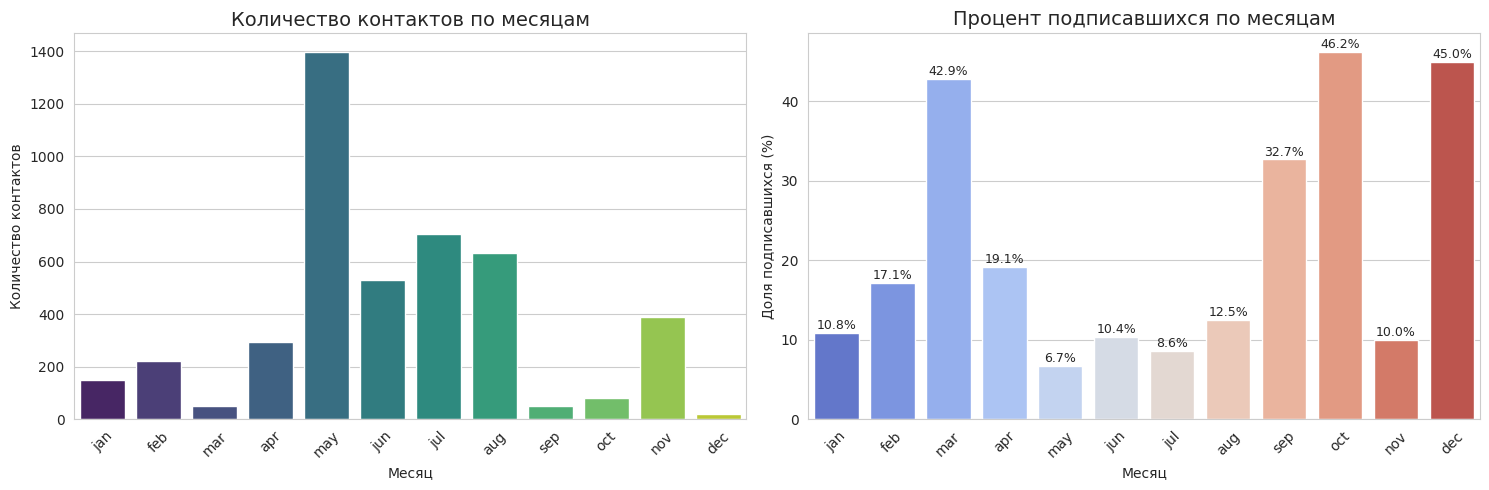

In [11]:
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
month_success = df.groupby('month')['y'].apply(lambda x: (x == 'yes').mean() * 100)
month_success = month_success.reindex(month_order)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Количество контактов по месяцам
month_counts = df['month'].value_counts().reindex(month_order)
sns.barplot(x=month_counts.index, y=month_counts.values, ax=axes[0], palette='viridis')
axes[0].set_title('Количество контактов по месяцам', fontsize=14)
axes[0].set_xlabel('Месяц')
axes[0].set_ylabel('Количество контактов')
axes[0].tick_params(axis='x', rotation=45)

# Процент успеха по месяцам
sns.barplot(x=month_success.index, y=month_success.values, ax=axes[1], palette='coolwarm')
axes[1].set_title('Процент подписавшихся по месяцам', fontsize=14)
axes[1].set_xlabel('Месяц')
axes[1].set_ylabel('Доля подписавшихся (%)')
axes[1].tick_params(axis='x', rotation=45)

# Добавление значений на столбцы
for i, v in enumerate(month_success.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 12. Анализ по возрасту и балансу

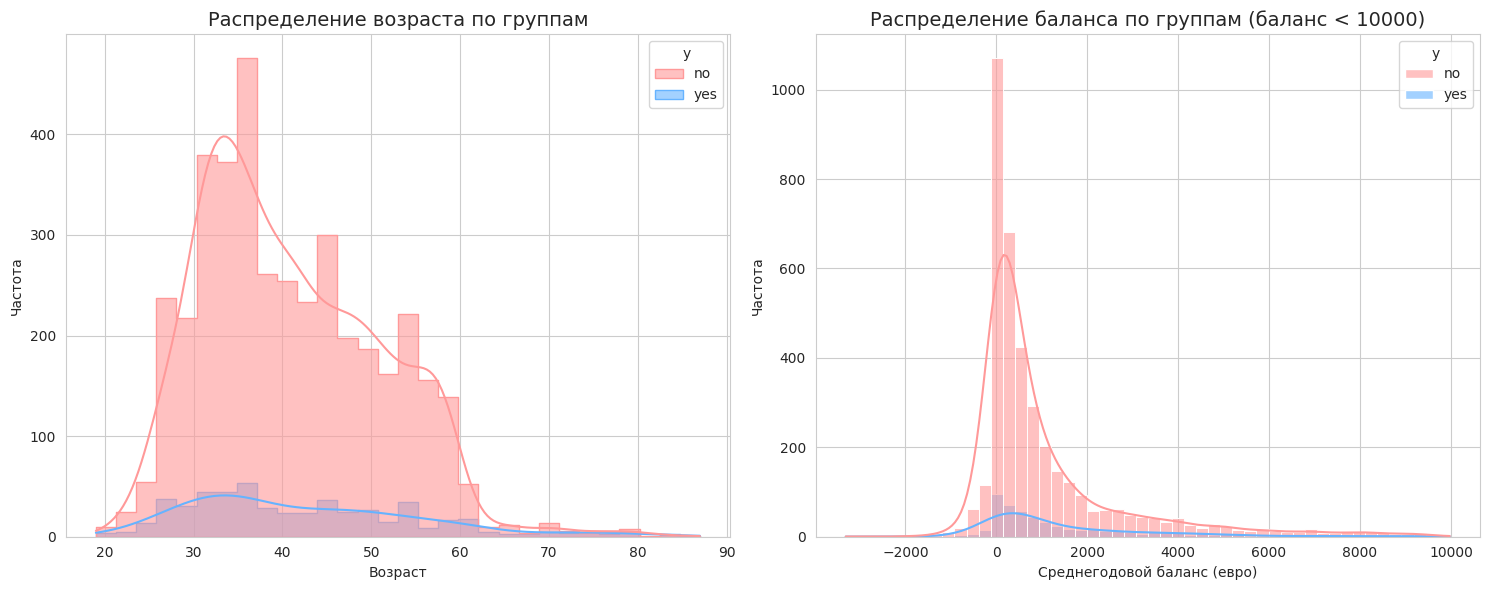

/tmp/ipykernel_8256/1387639172.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_success = df.groupby('age_group')['y'].apply(lambda x: (x == 'yes').mean() * 100)
/tmp/ipykernel_8256/1387639172.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_success.index, y=age_success.values, palette='Blues_d')


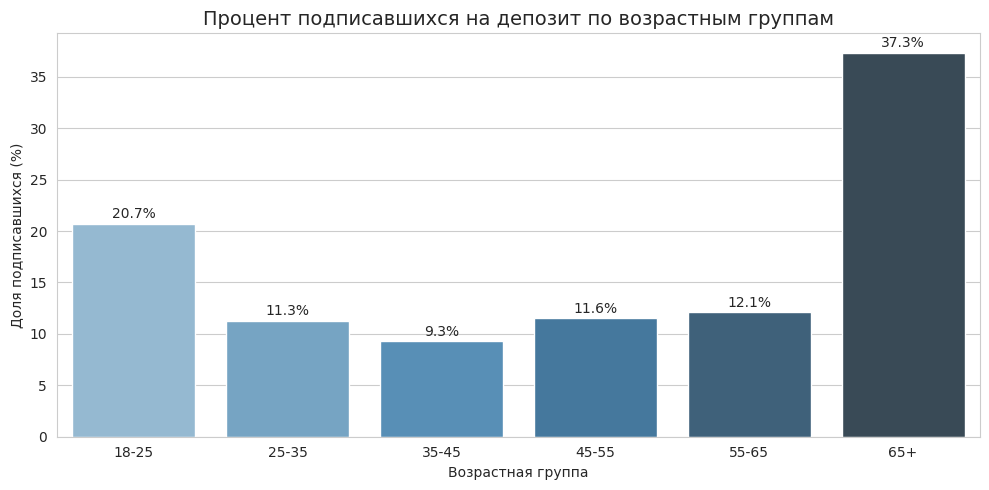

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Распределение по возрастам
sns.histplot(data=df, x='age', hue='y', bins=30, kde=True, ax=axes[0],
             palette=['#ff9999', '#66b3ff'], alpha=0.6, element="step")
axes[0].set_title('Распределение возраста по группам', fontsize=14)
axes[0].set_xlabel('Возраст')
axes[0].set_ylabel('Частота')

# Распределение по балансу (ограничим для наглядности)
balance_limited = df[df['balance'] < 10000]
sns.histplot(data=balance_limited, x='balance', hue='y', bins=50, kde=True, ax=axes[1],
             palette=['#ff9999', '#66b3ff'], alpha=0.6)
axes[1].set_title('Распределение баланса по группам (баланс < 10000)', fontsize=14)
axes[1].set_xlabel('Среднегодовой баланс (евро)')
axes[1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

# Возрастные группы
df['age_group'] = pd.cut(df['age'], bins=[18, 25, 35, 45, 55, 65, 100],
                          labels=['18-25', '25-35', '35-45', '45-55', '55-65', '65+'])
age_success = df.groupby('age_group')['y'].apply(lambda x: (x == 'yes').mean() * 100)

plt.figure(figsize=(10, 5))
sns.barplot(x=age_success.index, y=age_success.values, palette='Blues_d')
plt.title('Процент подписавшихся на депозит по возрастным группам', fontsize=14)
plt.xlabel('Возрастная группа')
plt.ylabel('Доля подписавшихся (%)')
for i, v in enumerate(age_success.values):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

## 13. Анализ по роду занятий

/tmp/ipykernel_8256/1322561136.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=job_counts.index, y=job_counts.values, ax=axes[0], palette='Set2')
/tmp/ipykernel_8256/1322561136.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=job_success.index, y=job_success.values, ax=axes[1], palette='coolwarm')


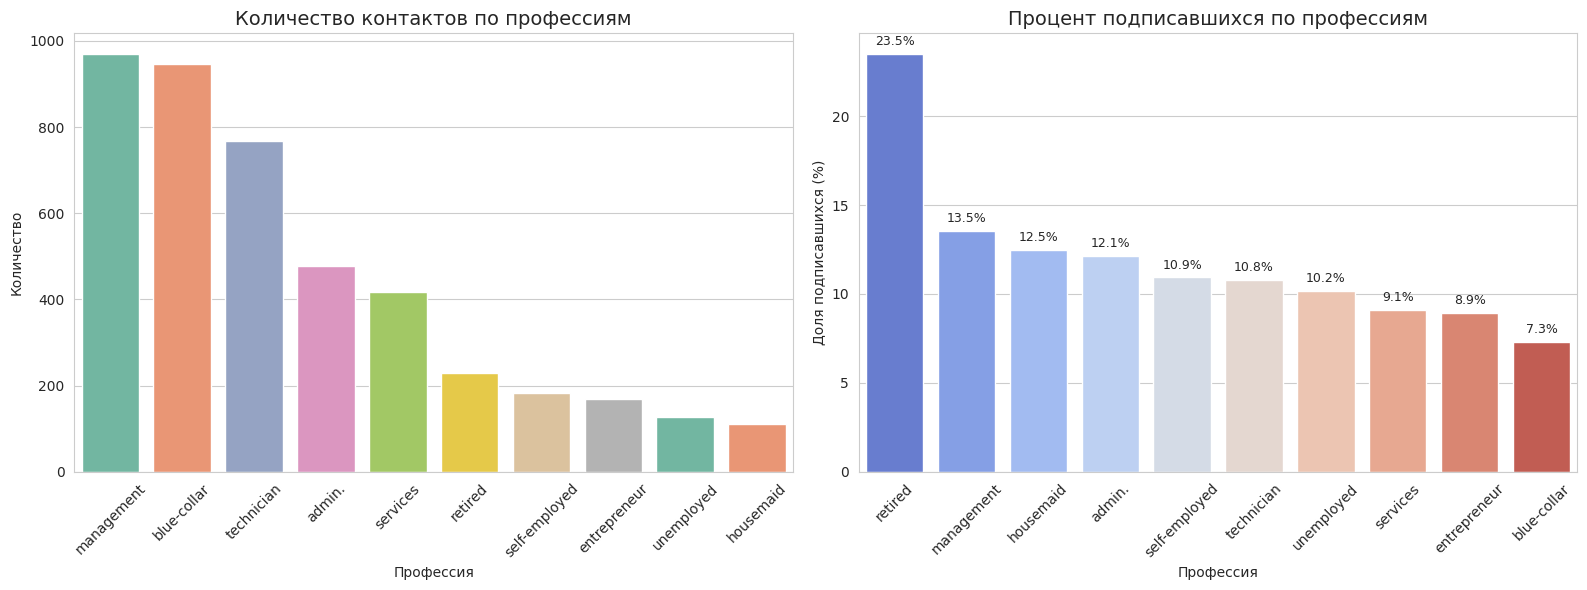

In [13]:
# Топ-10 профессий по количеству
top_jobs = df['job'].value_counts().head(10).index
df_jobs = df[df['job'].isin(top_jobs)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Количество контактов по профессиям
job_counts = df_jobs['job'].value_counts()
sns.barplot(x=job_counts.index, y=job_counts.values, ax=axes[0], palette='Set2')
axes[0].set_title('Количество контактов по профессиям', fontsize=14)
axes[0].set_xlabel('Профессия')
axes[0].set_ylabel('Количество')
axes[0].tick_params(axis='x', rotation=45)

# Процент успеха по профессиям
job_success = df_jobs.groupby('job')['y'].apply(lambda x: (x == 'yes').mean() * 100).sort_values(ascending=False)
sns.barplot(x=job_success.index, y=job_success.values, ax=axes[1], palette='coolwarm')
axes[1].set_title('Процент подписавшихся по профессиям', fontsize=14)
axes[1].set_xlabel('Профессия')
axes[1].set_ylabel('Доля подписавшихся (%)')
axes[1].tick_params(axis='x', rotation=45)

# Добавление значений
for i, v in enumerate(job_success.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 14. Анализ предыдущих кампаний

/tmp/ipykernel_8256/2034106356.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pdays_success.index, y=pdays_success.values, ax=axes[0], palette=['#ff9999', '#66b3ff'])
/tmp/ipykernel_8256/2034106356.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=poutcome_success.index, y=poutcome_success.values, ax=axes[1], palette='Set3')


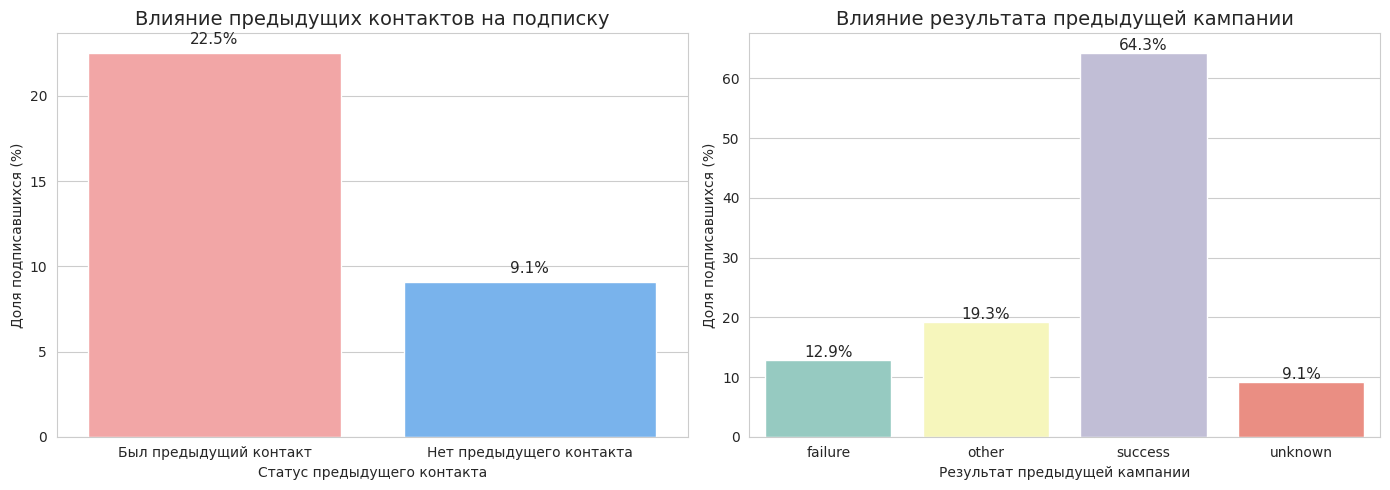

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Анализ pdays (дней с момента последнего контакта)
# Разделим на категории
df['pdays_category'] = df['pdays'].apply(lambda x: 'Нет предыдущего контакта' if x == -1 else 'Был предыдущий контакт')
pdays_success = df.groupby('pdays_category')['y'].apply(lambda x: (x == 'yes').mean() * 100)

sns.barplot(x=pdays_success.index, y=pdays_success.values, ax=axes[0], palette=['#ff9999', '#66b3ff'])
axes[0].set_title('Влияние предыдущих контактов на подписку', fontsize=14)
axes[0].set_xlabel('Статус предыдущего контакта')
axes[0].set_ylabel('Доля подписавшихся (%)')
for i, v in enumerate(pdays_success.values):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=11)

# Анализ poutcome (результат предыдущей кампании)
poutcome_success = df.groupby('poutcome')['y'].apply(lambda x: (x == 'yes').mean() * 100)
sns.barplot(x=poutcome_success.index, y=poutcome_success.values, ax=axes[1], palette='Set3')
axes[1].set_title('Влияние результата предыдущей кампании', fontsize=14)
axes[1].set_xlabel('Результат предыдущей кампании')
axes[1].set_ylabel('Доля подписавшихся (%)')
for i, v in enumerate(poutcome_success.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

## 15. Pairplot для ключевых признаков

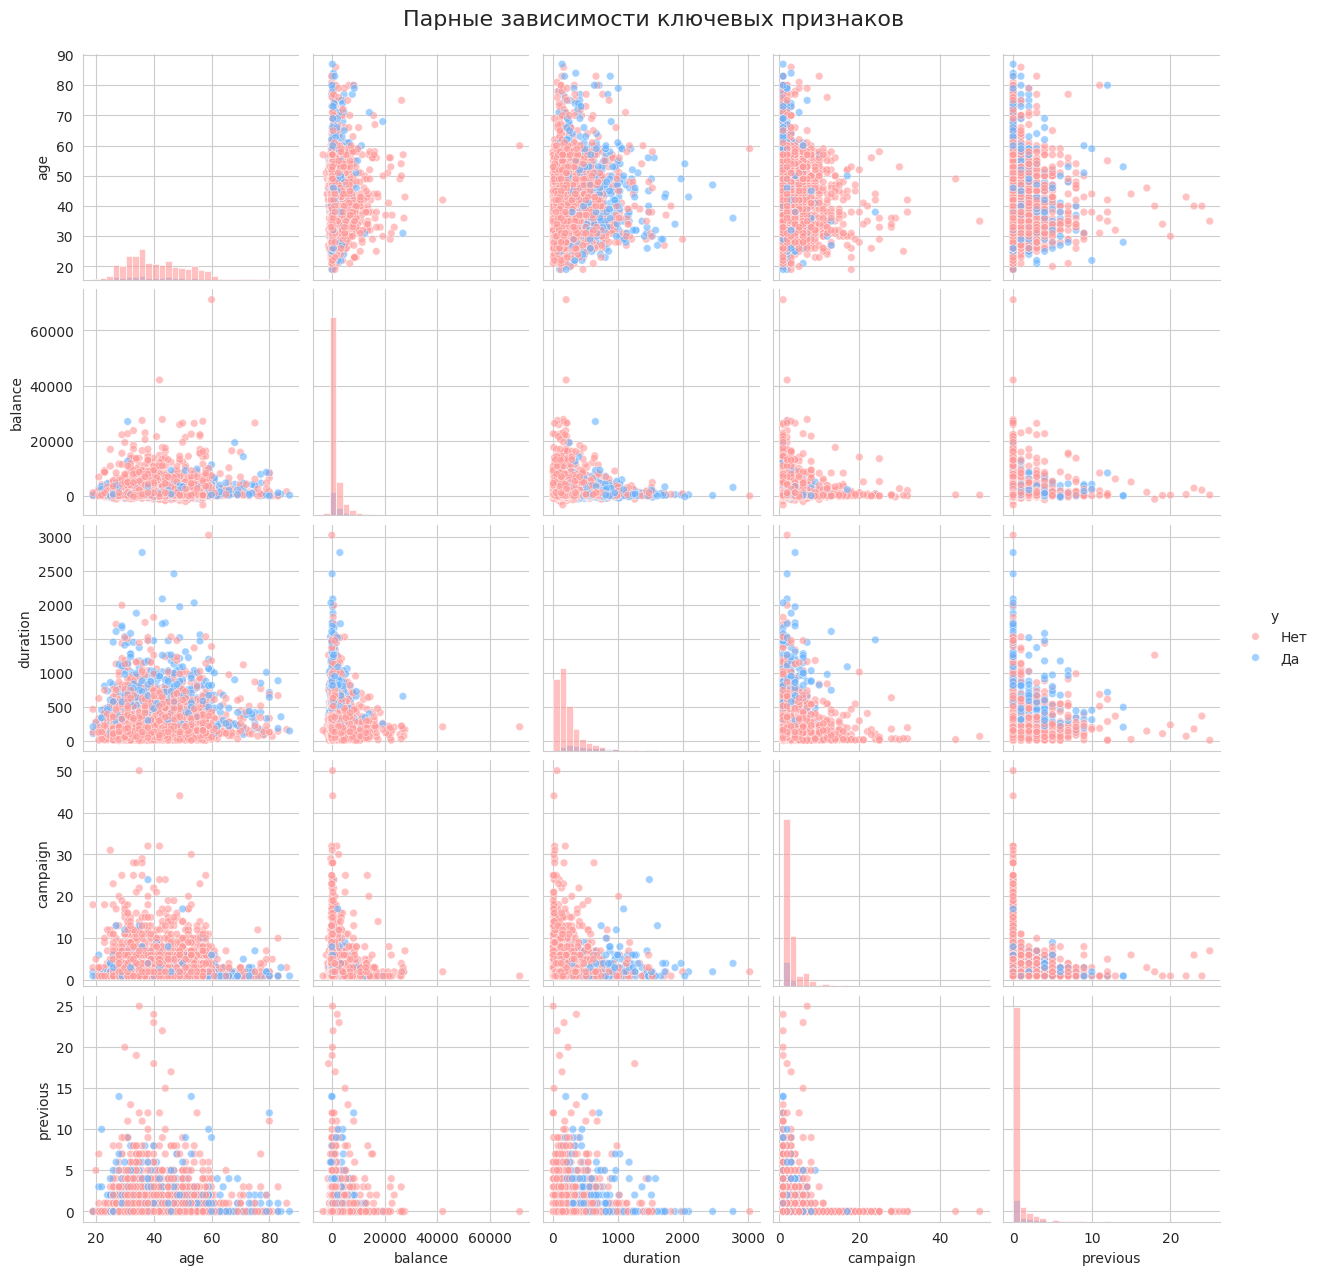

In [15]:
key_features = ['age', 'balance', 'duration', 'campaign', 'previous', 'y']
df_pair = df[key_features].copy()
# Преобразуем целевую переменную для лучшего отображения
df_pair['y'] = df_pair['y'].map({'yes': 'Да', 'no': 'Нет'})

# Создаем pairplot
sns.pairplot(df_pair, hue='y', palette=['#ff9999', '#66b3ff'],
             diag_kind='hist', plot_kws={'alpha': 0.6, 's': 30},
             diag_kws={'bins': 30, 'alpha': 0.6})
plt.suptitle('Парные зависимости ключевых признаков', fontsize=16, y=1.02)
plt.show()

  В ходе выполнения лабораторной работы был проведен визуальный анализ набора данных bank.csv, содержащего информацию о клиентах банка и результатах маркетинговых кампаний по привлечению к оформлению срочного депозита. Набор данных включает 17 признаков (категориальных и числовых) и целевую переменную y, отражающую факт подписки клиента на депозит. Общее количество записей в датасете составило 4521.

  Анализ распределения целевой переменной показал, что наблюдается значительный дисбаланс классов: лишь небольшая часть клиентов подписывается на срочный депозит, что нормально для прямого маркетинга.